In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import streamlit
import pickle

In [38]:
df = pd.read_csv("IceCreamSalesData.csv")
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [40]:
df.shape

(49, 2)

In [41]:
df.describe()

,Temperature (°C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


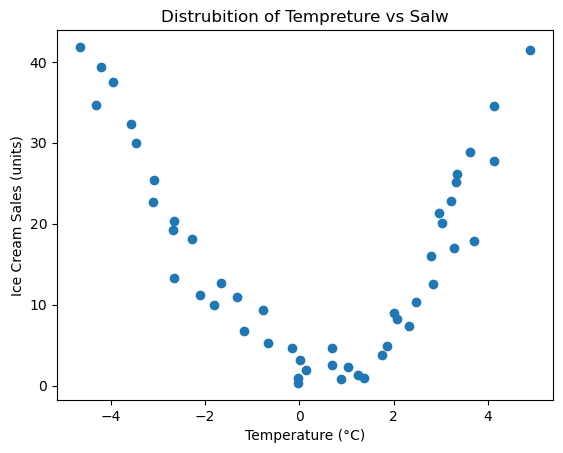

In [42]:
plt.scatter(df['Temperature (°C)'],df['Ice Cream Sales (units)'])
plt.title('Distrubition of Tempreture vs Salw')
plt.xlabel("Temperature (°C)")
plt.ylabel('Ice Cream Sales (units)')
plt.show()

In [43]:
corr = df.corr()
corr

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


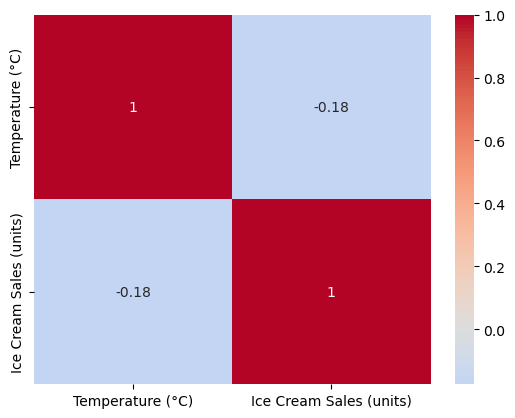

In [44]:
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

In [45]:
X = df[['Temperature (°C)']]  # Input featuru
y = df[['Ice Cream Sales (units)']]

In [46]:
X

,Temperature (°C)
0,-4.662263
1,-4.316559
2,-4.213985
3,-3.949661
4,-3.578554
5,-3.455712
6,-3.108440
7,-3.081303
8,-2.672461
9,-2.652287


In [47]:
# Trine-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [48]:
X_train

,Temperature (°C)
12,-2.111870
4,-3.578554
34,2.318591
8,-2.672461
3,-3.949661
6,-3.108440
40,3.211366
41,3.270044
46,4.130868
15,-1.326379


In [49]:
X_train.size

39

In [50]:
X_test.size

10

In [51]:
# Apply StandardScaler

scaler = StandardScaler()

scaled_X_train = scaler.fit_transform(X_train)  # To Aviode Data Likage
scaled_X_test = scaler.transform(X_test)

In [52]:
scaled_X_train

array([[-7.63693745e-01],
       [-1.29300680e+00],
       [ 8.35219704e-01],
       [-9.66006037e-01],
       [-1.42693611e+00],
       [-1.12334704e+00],
       [ 1.15741413e+00],
       [ 1.17859046e+00],
       [ 1.48925405e+00],
       [-4.80217223e-01],
       [-9.58725410e-01],
       [-4.24908615e-01],
       [ 2.47035833e-01],
       [ 7.47346123e-01],
       [ 6.26411340e-01],
       [-1.68410760e+00],
       [ 1.20236897e+00],
       [ 7.19994113e-01],
       [-1.24867422e+00],
       [ 4.89205154e-01],
       [-8.27352862e-01],
       [ 1.00348341e+00],
       [-1.55934642e+00],
       [-1.37714965e-02],
       [-1.52232814e+00],
       [ 1.02041776e+00],
       [ 8.90564054e-01],
       [ 5.23220294e-02],
       [ 1.08866734e+00],
       [-9.58440754e-01],
       [ 1.56744775e-03],
       [-2.44690311e-01],
       [ 1.76647736e+00],
       [-1.45875476e-02],
       [-1.11355361e+00],
       [ 1.19520171e+00],
       [-6.00743535e-01],
       [ 4.46222656e-01],
       [ 1.0

In [53]:
# Apllying Linaer Regression Model

regression = LinearRegression()
regression.fit(scaled_X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
coef = regression.coef_
intercept = regression.intercept_

print(f'coefficient{coef}')
print(f'intercept{intercept}')

coefficient[[-3.17710024]]
intercept[17.13432359]


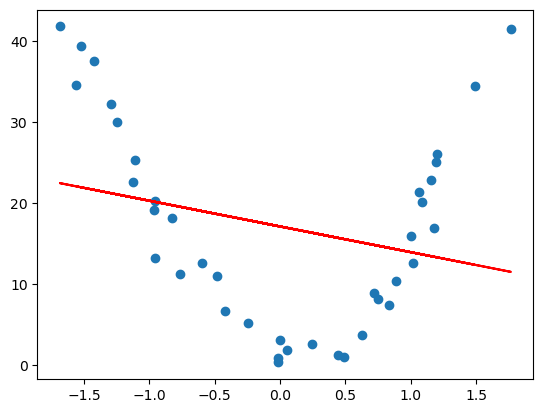

In [55]:
# Plot Best fit Line 
plt.scatter(scaled_X_train, y_train)
plt.plot(scaled_X_train, regression.predict(scaled_X_train), color="red")
plt.show()

In [56]:
# Prediction on test Data
y_pred = regression.predict(X_test)
y_pred

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([[22.91327071],
       [ 5.3661618 ],
       [ 4.00167239],
       [ 5.66251841],
       [19.59127066],
       [13.88039848],
       [14.35466261],
       [14.93069045],
       [11.25493462],
       [17.60972856]])

In [57]:
# 

def test_metrics(y_test, y_pred_test):
    result = [{
        'MAS': mean_absolute_error(y_test, y_pred_test),
        'MSE': mean_squared_error(y_test, y_pred_test),
        'RMSE':np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'R2_SCORE': r2_score(y_test, y_pred_test)
    }]
    return pd.DataFrame(result)

In [58]:
metrics = test_metrics(y_test, y_pred)
metrics

,MAS,MSE,RMSE,R2_SCORE
0,13.729219,216.04455,14.698454,-1.278886


In [59]:
# Plynomial Regression

poly = PolynomialFeatures(degree=2, include_bias=False)
poly

,degree,2
,interaction_only,False
,include_bias,False
,order,'C'


In [60]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [61]:
X_train_poly

array([[-2.11186969e+00,  4.45999359e+00],
       [-3.57855372e+00,  1.28060467e+01],
       [ 2.31859124e+00,  5.37586534e+00],
       [-2.67246083e+00,  7.14204687e+00],
       [-3.94966109e+00,  1.55998227e+01],
       [-3.10844012e+00,  9.66239999e+00],
       [ 3.21136614e+00,  1.03128725e+01],
       [ 3.27004407e+00,  1.06931882e+01],
       [ 4.13086796e+00,  1.70640701e+01],
       [-1.32637898e+00,  1.75928121e+00],
       [-2.65228679e+00,  7.03462523e+00],
       [-1.17312327e+00,  1.37621820e+00],
       [ 6.88780908e-01,  4.74419139e-01],
       [ 2.07510060e+00,  4.30604249e+00],
       [ 1.74000001e+00,  3.02760004e+00],
       [-4.66226268e+00,  2.17366933e+01],
       [ 3.33593241e+00,  1.11284451e+01],
       [ 1.99931037e+00,  3.99724195e+00],
       [-3.45571170e+00,  1.19419433e+01],
       [ 1.35981267e+00,  1.84909051e+00],
       [-2.28826400e+00,  5.23615213e+00],
       [ 2.78483646e+00,  7.75531413e+00],
       [-4.31655945e+00,  1.86326855e+01],
       [-3.

In [62]:
# Model Traning

regression = LinearRegression()
regression.fit(X_train_poly, y_train) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
# coefficient (slope)
coef = regression.coef_
coef

array([[-0.70641926,  1.87145125]])

In [64]:
# Intercept
intercept = regression.intercept_
intercept

array([2.76830583])

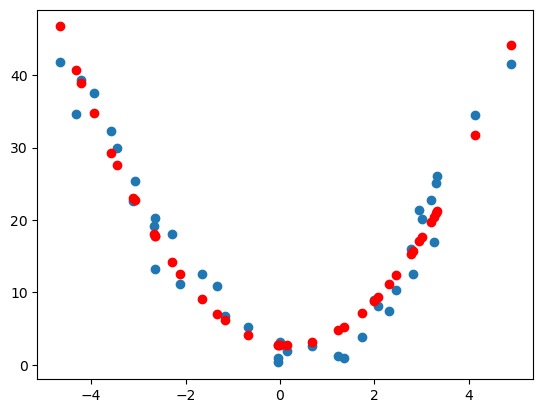

In [65]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, regression.predict(X_train_poly), color="r")  # predict evaluate model
plt.show()

In [66]:
y_pred_test = regression.predict(X_test_poly)
y_pred_test

array([[10.24499852],
       [25.82807714],
       [31.8241041 ],
       [24.61704203],
       [ 4.43380256],
       [ 4.00785672],
       [ 3.58277491],
       [ 3.17865087],
       [ 7.86990452],
       [ 2.91591368]])

In [67]:
metrics = test_metrics(y_test, y_pred_test)
metrics

,MAS,MSE,RMSE,R2_SCORE
0,3.229982,14.878796,3.857304,0.843055


In [68]:
def poly_regression(degree):
    scaler = StandardScaler()
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    regression = LinearRegression()

    pipeline = Pipeline([          # used for streamline(sequence)
        ('scaler', scaler),
        ('poly', poly),
        ('regression', regression),
    ])

    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    print(score)

    X_sorted = np.sort(X_train, axis=0)

    y_pred = pipeline.predict(X_sorted)

    plt.plot(X_sorted, y_pred, "r", label="Model fit")
    plt.scatter(X_train, y_train, label="Training Points")
    plt.scatter(X_test, y_test, label="Test Points")
    plt.legend()
    plt.show()

-0.5751270190188227


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


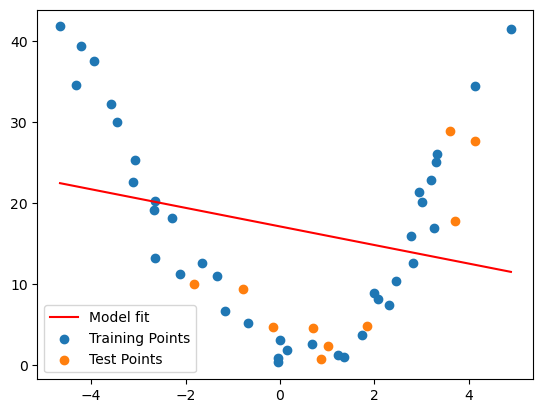

0.8430551371938841


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


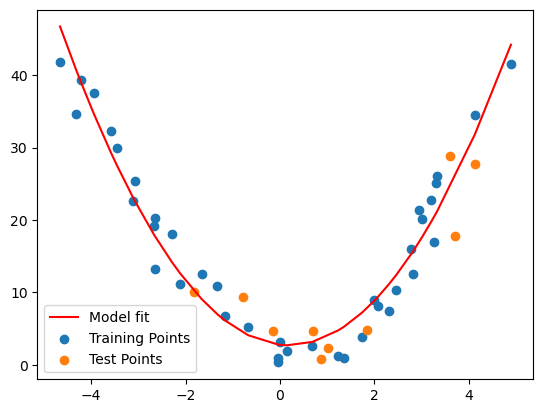

0.8405107685716922


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


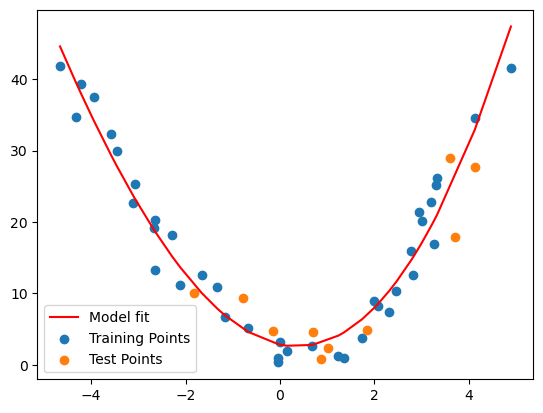

0.8054468908427653


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


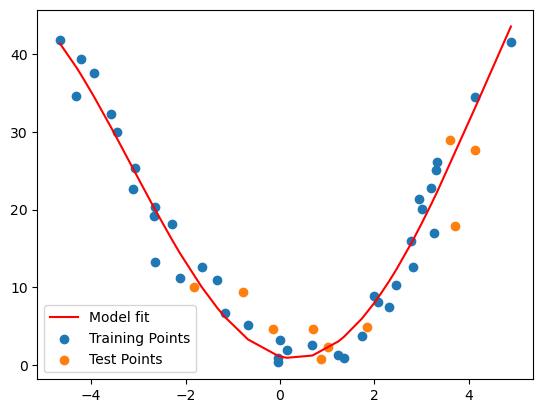

0.7781622233034707


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


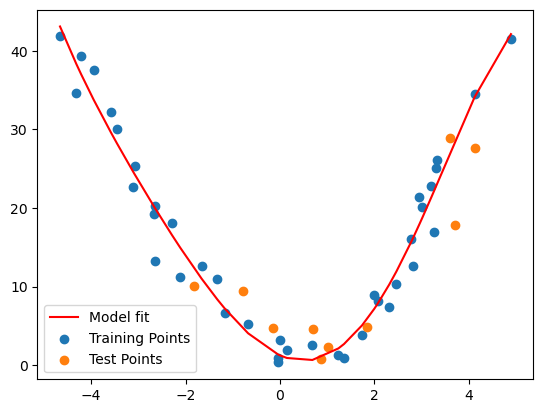

0.7313950333962976


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


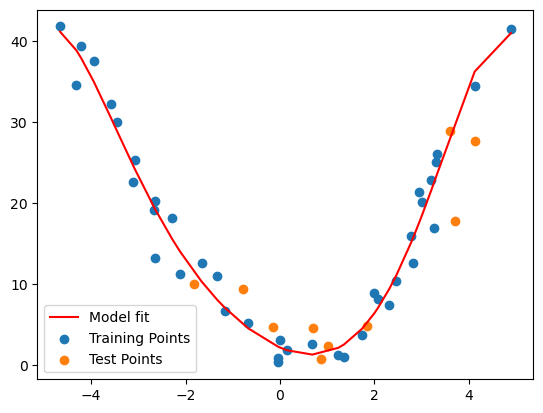

0.7690369411276926


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


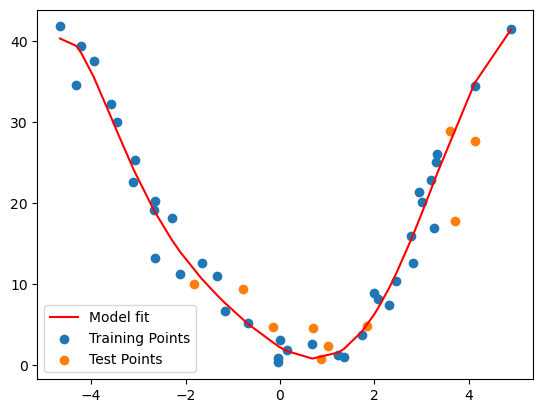

0.7759596479486324


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


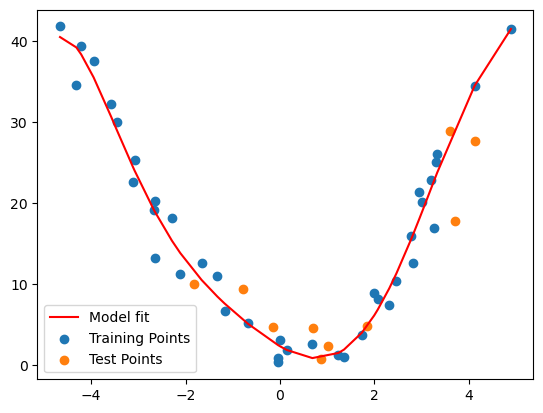

0.7741537994038152


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


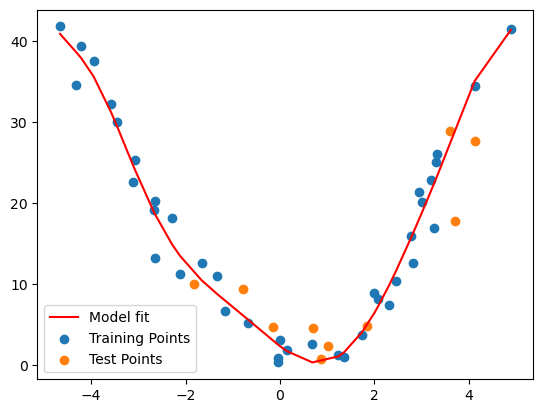

0.7432997364943155


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


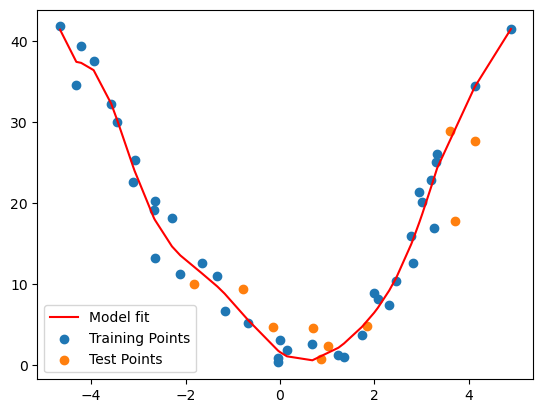

In [69]:
for degree in [1,2,3,4,5,6,7,8,9,10]:
    poly_regression(degree)

In [70]:
# RESULT
# The relationship between Ice Cream Sales 

In [71]:
# save model
pickle.dump(regression, open('model.pkl','wb'))

print('Model trained and saved successfully!')

Model trained and saved successfully!
